# STAT3612: Multimodal Brain Tumor Classification — Full Pipeline (Micro-F1)

This notebook implements the **three-stage pipeline** described in our proposal:

| Section | Proposal Stage | Content |
|---|---|---|
| **0. Setup & EDA** | Preliminary Findings | Environment, data loading, EDA findings (class imbalance, missing data, multimodal incompleteness) |
| **1. Feature Engineering** | Data Processing | Load & encode all 4 modalities; PCA; standardize |
| **2. Single-Modality Baselines** | Stage 1 | Independent classifiers per modality to understand individual contributions |
| **3. Multimodal Fusion** | Stage 2 | Early fusion (concatenated features) and late fusion (voting/stacking) |
| **4. Optimization** | Stage 3 | Class imbalance mitigation, feature selection *(TODO)* |
| **5. Model Analysis** | Analysis Plan | Model comparison, modality ablation, interpretability |
| **6. Kaggle Submission** | — | Generate final submission file |

**Primary evaluation metric**: **Micro-F1** (aligned with Kaggle leaderboard F1-Beta Micro scoring)  
**Secondary metrics**: Weighted-F1, Accuracy, Per-class Precision/Recall/F1  
**5-class target**: Glioma, Meningioma, Brain Metastase Tumour, Tumors of the sellar region, Pineal tumour and Choroid plexus tumour

---
# 0. Setup & Exploratory Data Analysis

## 0.1 Environment

In [1]:
import numpy as np
import pandas as pd
import json, os, warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

def _find_train_val_root() -> Path:
    """Locate folder containing train.json + val.json (dataset/kaggle-dataset or ./kaggle-dataset)."""
    for d in [Path.cwd(), *Path.cwd().resolve().parents]:
        for name in ('dataset/kaggle-dataset', 'kaggle-dataset'):
            p = d / name
            if (p / 'train.json').is_file() and (p / 'val.json').is_file():
                return p.resolve()
    raise FileNotFoundError(
        'Cannot find train.json and val.json. Place data under dataset/kaggle-dataset/ (see dataset/README.md).'
    )


def _find_test_root(train_val: Path) -> Path:
    """Monolithic layout: test.json next to train. Split layout: sibling new_test/test.json."""
    if (train_val / 'test.json').is_file():
        return train_val.resolve()
    cand = train_val.parent / 'new_test' / 'test.json'
    if cand.is_file():
        return cand.parent.resolve()
    raise FileNotFoundError(
        f'Cannot find test.json next to {train_val} or at {cand}. See dataset/README.md.'
    )


TRAIN_VAL_ROOT = _find_train_val_root()
TEST_ROOT = _find_test_root(TRAIN_VAL_ROOT)
BASE_DIR = str(TRAIN_VAL_ROOT)
print('TRAIN_VAL_ROOT =', TRAIN_VAL_ROOT)
print('TEST_ROOT =', TEST_ROOT)

TRAIN_VAL_ROOT = /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team/dataset/kaggle-dataset
TEST_ROOT = /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team/dataset/new_test


## 0.2 Load Metadata

In [2]:
with open(TRAIN_VAL_ROOT / 'train.json') as f:
    train_meta = json.load(f)
with open(TRAIN_VAL_ROOT / 'val.json') as f:
    val_meta = json.load(f)
with open(TEST_ROOT / 'test.json') as f:
    test_meta = json.load(f)

print(f'Splits — Train: {len(train_meta)}, Val: {len(val_meta)}, Test: {len(test_meta)}')

train_labels = {k: v['Overall_class'] for k, v in train_meta.items()}
val_labels   = {k: v['Overall_class'] for k, v in val_meta.items()}

Splits — Train: 1983, Val: 283, Test: 378


## 0.3 EDA: Class Imbalance (~40:1)

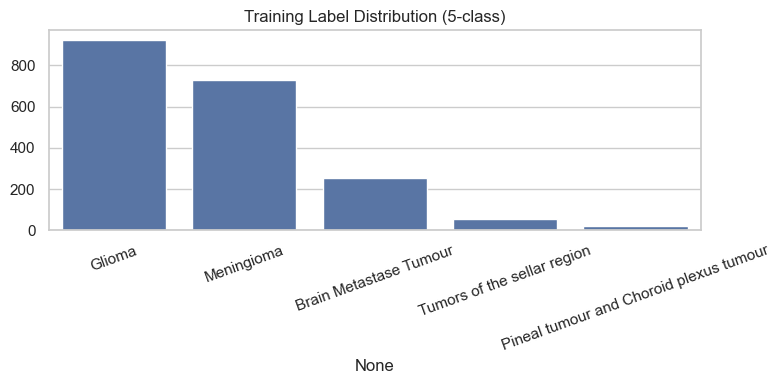

Class frequencies:
  Glioma: 924 (46.6%)
  Meningioma: 728 (36.7%)
  Brain Metastase Tumour: 252 (12.7%)
  Tumors of the sellar region: 56 (2.8%)
  Pineal tumour and Choroid plexus tumour: 23 (1.2%)

Imbalance ratio (max/min): 40:1


In [3]:
label_counts = pd.Series(Counter(train_labels.values())).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, ax=ax)
ax.set_title('Training Label Distribution (5-class)')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

print('Class frequencies:')
for cls, cnt in label_counts.items():
    print(f'  {cls}: {cnt} ({cnt/len(train_labels)*100:.1f}%)')
print(f'\nImbalance ratio (max/min): {label_counts.max()/label_counts.min():.0f}:1')

## 0.4 EDA: Multimodal Incompleteness (~20% missing 1 modality)

In [4]:
MODALITIES = ['ax_t1', 'ax_t1c', 'ax_t2', 'ax_t2f']

for split_name, meta in [('train', train_meta), ('val', val_meta), ('test', test_meta)]:
    n_paths = [len(v.get('image_path', [])) for v in meta.values()]
    counts = Counter(n_paths)
    total = len(meta)
    print(f'[{split_name}] modality completeness: ', end='')
    for k in sorted(counts):
        print(f'{k}-mod={counts[k]} ({counts[k]/total*100:.1f}%)  ', end='')
    print()

[train] modality completeness: 3-mod=390 (19.7%)  4-mod=1593 (80.3%)  
[val] modality completeness: 3-mod=61 (21.6%)  4-mod=222 (78.4%)  
[test] modality completeness: 1-mod=10 (2.6%)  2-mod=9 (2.4%)  3-mod=81 (21.4%)  4-mod=278 (73.5%)  


## 0.5 EDA: Missing Demographics (JSON ~70% vs CSV ~0%)

In [5]:
def _clean_cols(df):
    df.columns = [str(c).replace(chr(0xFEFF), '').strip() for c in df.columns]
    return df

clin_train = _clean_cols(pd.read_csv(os.path.join(BASE_DIR, 'clinical_information', 'train_patient_info.csv')))

json_age_missing = sum(1 for v in train_meta.values() if not v.get('Age'))
json_sex_missing = sum(1 for v in train_meta.values() if not v.get('Sex'))
clin_age_missing = clin_train['Age'].isna().sum()
clin_sex_missing = clin_train['Sex'].isna().sum()

print(f'JSON  Age missing: {json_age_missing}/{len(train_meta)} ({json_age_missing/len(train_meta)*100:.1f}%)')
print(f'JSON  Sex missing: {json_sex_missing}/{len(train_meta)} ({json_sex_missing/len(train_meta)*100:.1f}%)')
print(f'CSV   Age missing: {clin_age_missing}/{len(clin_train)} ({clin_age_missing/len(clin_train)*100:.1f}%)')
print(f'CSV   Sex missing: {clin_sex_missing}/{len(clin_train)} ({clin_sex_missing/len(clin_train)*100:.1f}%)')
print('\n=> Clinical CSV is the preferred source for demographics.')

JSON  Age missing: 1380/1983 (69.6%)
JSON  Sex missing: 1380/1983 (69.6%)
CSV   Age missing: 1384/1983 (69.8%)
CSV   Sex missing: 0/1983 (0.0%)

=> Clinical CSV is the preferred source for demographics.


## 0.6 EDA: Radiomics Feature Correlation

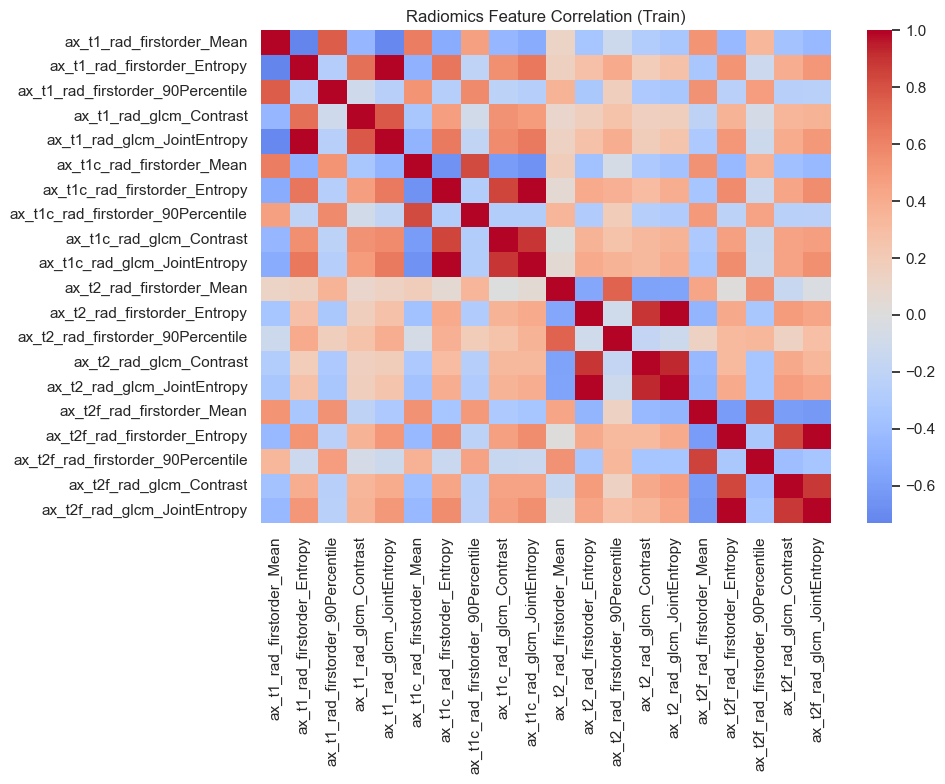

Feature pairs with |r| > 0.95: 4


In [6]:
RADIOMICS_FEAT_COLS = ['rad_firstorder_Mean', 'rad_firstorder_Entropy',
                       'rad_firstorder_90Percentile', 'rad_glcm_Contrast',
                       'rad_glcm_JointEntropy']

rad_frames = []
for mod in MODALITIES:
    df = _clean_cols(pd.read_csv(os.path.join(BASE_DIR, 'radiomics_info', 'train', f'{mod}_radiomics_train.csv')))
    for c in RADIOMICS_FEAT_COLS:
        df = df.rename(columns={c: f'{mod}_{c}'})
    rad_frames.append(df)

rad_all = rad_frames[0][['case_id']].copy()
for df in rad_frames:
    rad_all = rad_all.merge(df.drop(columns=['sex','age','modality'], errors='ignore'), on='case_id', how='left')

rad_numeric = rad_all.select_dtypes(include=[np.number]).drop(columns=['case_id'], errors='ignore')
corr = rad_numeric.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, xticklabels=True, yticklabels=True)
plt.title('Radiomics Feature Correlation (Train)')
plt.tight_layout(); plt.show()

high_corr = (corr.abs() > 0.95).sum().sum() - len(corr)
print(f'Feature pairs with |r| > 0.95: {high_corr // 2}')

---
# 1. Feature Engineering

We load and encode all four modalities, then combine them into a unified feature matrix.

## 1.1 Image Features (2048-d × 4 modalities, zero-pad if missing)

In [7]:
def load_image_features(meta_dict, base_dir=None):
    if base_dir is None:
        base_dir = str(TRAIN_VAL_ROOT)
    case_ids = sorted(meta_dict.keys(), key=int)
    features = []
    for cid in case_ids:
        case_feats = []
        for mod in MODALITIES:
            npy_path = os.path.join(base_dir, 'image_features', 'image_features', cid, mod, 'image.npy')
            if os.path.exists(npy_path):
                case_feats.append(np.load(npy_path))
            else:
                case_feats.append(np.zeros(2048, dtype=np.float32))
        features.append(np.concatenate(case_feats))
    return np.array(features), case_ids

X_img_train, train_ids = load_image_features(train_meta)
X_img_val,   val_ids   = load_image_features(val_meta)
X_img_test,  test_ids  = load_image_features(test_meta, str(TEST_ROOT))
print(f'Image — Train: {X_img_train.shape}, Val: {X_img_val.shape}, Test: {X_img_test.shape}')

Image — Train: (1983, 8192), Val: (283, 8192), Test: (378, 8192)


## 1.2 Radiomics Features (5 × 4 modalities, NaN → 0)

In [8]:
def load_radiomics(split, case_ids, base_dir=None):
    if base_dir is None:
        base_dir = str(TEST_ROOT if split == 'test' else TRAIN_VAL_ROOT)
    all_feats = pd.DataFrame({'case_id': [int(c) for c in case_ids]})
    for mod in MODALITIES:
        df = _clean_cols(pd.read_csv(os.path.join(base_dir, 'radiomics_info', split, f'{mod}_radiomics_{split}.csv')))
        rename = {c: f'{mod}_{c}' for c in RADIOMICS_FEAT_COLS}
        df = df[['case_id'] + RADIOMICS_FEAT_COLS].rename(columns=rename)
        all_feats = all_feats.merge(df, on='case_id', how='left')
    feat_cols = [c for c in all_feats.columns if c != 'case_id']
    all_feats[feat_cols] = all_feats[feat_cols].fillna(0)
    all_feats = all_feats.set_index('case_id').loc[[int(c) for c in case_ids]]
    return all_feats.values

X_rad_train = load_radiomics('train', train_ids)
X_rad_val   = load_radiomics('val',   val_ids)
X_rad_test  = load_radiomics('test',  test_ids)
print(f'Radiomics — Train: {X_rad_train.shape}, Val: {X_rad_val.shape}, Test: {X_rad_test.shape}')

Radiomics — Train: (1983, 20), Val: (283, 20), Test: (378, 20)


## 1.3 Clinical Features (from CSV; demographics sourced from clinical_information)

In [9]:
def _clinical_csv_path(split: str, base_dir: str) -> str:
    root = Path(base_dir)
    flat = root / 'clinical_information' / f'{split}_patient_info.csv'
    nested = root / 'clinical_information' / split / f'{split}_patient_info.csv'
    if nested.is_file():
        return str(nested)
    if flat.is_file():
        return str(flat)
    raise FileNotFoundError(
        f'Could not find clinical CSV for split={split!r} under {base_dir} (tried {nested} and {flat}).'
    )


def load_clinical(split, case_ids, base_dir=None):
    if base_dir is None:
        base_dir = str(TEST_ROOT if split == 'test' else TRAIN_VAL_ROOT)
    df = _clean_cols(pd.read_csv(_clinical_csv_path(split, base_dir)))
    df = df.set_index('case_id').loc[[int(c) for c in case_ids]].reset_index()
    return df

df_clin_train = load_clinical('train', train_ids)
df_clin_val   = load_clinical('val',   val_ids)
df_clin_test  = load_clinical('test',  test_ids)

sex_map = {'female': 0, 'male': 1, 'unknown': 2}
for df in [df_clin_train, df_clin_val, df_clin_test]:
    df['Sex_enc'] = df['Sex'].map(sex_map)

train_age_median = df_clin_train['Age'].median()
for df in [df_clin_train, df_clin_val, df_clin_test]:
    df['Age_filled'] = df['Age'].fillna(train_age_median)

intensity_map = {'hypointense': 0, 'isointense': 1, 'hyperintense': 2,
                 'heterogeneous': 3, 'homogeneous': 4, 'unknown': 5}
intensity_cols = ['Signal Intensity (T1)', 'Signal Intensity (T1c)',
                  'Signal Intensity (T2)', 'Signal Intensity (T2-FLAIR)']
for df in [df_clin_train, df_clin_val, df_clin_test]:
    for col in intensity_cols:
        df[col + '_enc'] = df[col].map(intensity_map).fillna(5).astype(int)

location_keywords = ['frontal', 'temporal', 'parietal', 'occipital', 'cerebellum',
                     'sellar', 'sella', 'pituitary', 'pineal', 'ventricle',
                     'brainstem', 'cerebellopontine', 'thalamus', 'basal',
                     'left', 'right', 'bilateral', 'midline']
for df in [df_clin_train, df_clin_val, df_clin_test]:
    loc_lower = df['Tumor Location'].str.lower().fillna('')
    for kw in location_keywords:
        df[f'loc_{kw}'] = loc_lower.str.contains(kw).astype(int)

clinical_feat_cols = (['Sex_enc', 'Age_filled'] +
                      [c + '_enc' for c in intensity_cols] +
                      [f'loc_{kw}' for kw in location_keywords])

X_clin_train = df_clin_train[clinical_feat_cols].values.astype(float)
X_clin_val   = df_clin_val[clinical_feat_cols].values.astype(float)
X_clin_test  = df_clin_test[clinical_feat_cols].values.astype(float)
print(f'Clinical — Train: {X_clin_train.shape}, Val: {X_clin_val.shape}, Test: {X_clin_test.shape}')

Clinical — Train: (1983, 24), Val: (283, 24), Test: (378, 24)


## 1.4 Text Features (TF-IDF from radiology reports)

In [10]:
def _report_to_text(report) -> str:
    """Normalize JSON report field: training data is str; some test cases use {finding, impression}."""
    if report is None:
        return ''
    if isinstance(report, str):
        return report
    if isinstance(report, dict):
        parts = []
        for key in ('finding', 'impression', 'Finding', 'Impression'):
            if key in report and report[key]:
                parts.append(str(report[key]))
        if parts:
            return ' '.join(parts)
        return ' '.join(str(v) for v in report.values() if v not in (None, ''))
    return str(report)


def get_reports(meta_dict, case_ids):
    return [_report_to_text(meta_dict[c].get('report')) for c in case_ids]

tfidf = TfidfVectorizer(max_features=500, ngram_range=(1, 2), stop_words='english', min_df=3)
X_text_train = tfidf.fit_transform(get_reports(train_meta, train_ids)).toarray()
X_text_val   = tfidf.transform(get_reports(val_meta, val_ids)).toarray()
X_text_test  = tfidf.transform(get_reports(test_meta, test_ids)).toarray()
print(f'Text — Train: {X_text_train.shape}, Val: {X_text_val.shape}, Test: {X_text_test.shape}')

Text — Train: (1983, 500), Val: (283, 500), Test: (378, 500)


## 1.5 PCA, Standardize, Encode Labels

In [11]:
pca_img = PCA(n_components=256, random_state=SEED)
X_img_train_pca = pca_img.fit_transform(X_img_train)
X_img_val_pca   = pca_img.transform(X_img_val)
X_img_test_pca  = pca_img.transform(X_img_test)
print(f'PCA explained variance (256 comp): {pca_img.explained_variance_ratio_.sum():.4f}')

# Early-fusion feature matrix
X_train_all = np.hstack([X_img_train_pca, X_rad_train, X_clin_train, X_text_train])
X_val_all   = np.hstack([X_img_val_pca,   X_rad_val,   X_clin_val,   X_text_val])
X_test_all  = np.hstack([X_img_test_pca,  X_rad_test,  X_clin_test,  X_text_test])
print(f'Early-fusion features: {X_train_all.shape[1]}d (img 256 + rad {X_rad_train.shape[1]} + clin {X_clin_train.shape[1]} + text {X_text_train.shape[1]})')

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_all)
X_val_scaled   = scaler.transform(X_val_all)
X_test_scaled  = scaler.transform(X_test_all)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform([train_labels[c] for c in train_ids])
y_val   = label_encoder.transform([val_labels[c] for c in val_ids])
print(f'Labels: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}')

# Class weights for imbalance handling
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))
sample_weights_train = np.array([class_weight_dict[y] for y in y_train])
for idx, w in class_weight_dict.items():
    print(f'  {label_encoder.inverse_transform([idx])[0]}: weight={w:.3f}')

PCA explained variance (256 comp): 0.9218
Early-fusion features: 800d (img 256 + rad 20 + clin 24 + text 500)
Labels: {np.str_('Brain Metastase Tumour'): 0, np.str_('Glioma'): 1, np.str_('Meningioma'): 2, np.str_('Pineal tumour and Choroid plexus tumour'): 3, np.str_('Tumors of the sellar region'): 4}
  Brain Metastase Tumour: weight=1.574
  Glioma: weight=0.429
  Meningioma: weight=0.545
  Pineal tumour and Choroid plexus tumour: weight=17.243
  Tumors of the sellar region: weight=7.082


---
# 2. Stage 1 — Single-Modality Baselines

Before fusion, we evaluate each modality independently to understand its discriminative power. This directly informs which modalities are worth fusing and which fusion strategy to use.

**Methodology (Lecture 4.1 — Cross-Validation)**:

For each modality we follow a two-step evaluation protocol:

1. **Primary**: **Stratified 5-fold CV on the training set** — produces `mean ± std` Micro-F1 across folds. This is the number we use for **model selection**, because it captures generalization variance.
2. **Reference**: **Held-out `val.json` evaluation** — a single-point estimate on data never seen during CV or training. Used to confirm that CV results transfer.

After CV-based selection, we **retrain the chosen model on the full training set** and report the held-out metrics.

**Evaluation metrics** (aligned with Kaggle & proposal):

| Metric | Role | Rationale |
|---|---|---|
| **Micro-F1** | **Primary** | Treats all 5 classes equally; directly penalizes poor minority-class recall — critical given ~40:1 class imbalance. This is the metric we optimize toward. |
| **Weighted-F1** | Secondary | Weights each class by support; reflects overall sample-level performance. |
| **Accuracy** | Reference | Easy to interpret but misleading under class imbalance (a model predicting only Glioma/Meningioma can achieve >80% accuracy). |
| **Per-class Precision / Recall / F1** | Diagnostic | Identifies which specific tumor types are under-served by each modality. |

> **Note on Kaggle scoring**: The competition leaderboard uses **F1 score**. Since our task is multiclass (5 classes), the Kaggle F1-Beta (Micro) computes F1 per sample and averages across all samples. Our primary metric (Micro-F1) is therefore directly aligned with the competition evaluation.

In [12]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def eval_modality(X_tr, X_va, y_tr, y_va, name, model=None):
    """
    Two-step evaluation per Lecture 4.1:
      1. Stratified 5-fold CV on training set  →  primary (model selection)
      2. Retrain on full training set → eval on held-out val  →  reference
    """
    if model is None:
        model = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                                   class_weight='balanced', random_state=SEED, verbose=-1)

    # ── Step 1: 5-fold CV on training set (primary evaluation) ──
    cv_pipe = make_pipeline(StandardScaler(), clone(model))
    cv_scores = cross_val_score(cv_pipe, X_tr, y_tr, cv=skf, scoring='f1_micro', n_jobs=-1)

    # ── Step 2: Retrain on full training set → held-out val (reference) ──
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_va_s = sc.transform(X_va)
    model.fit(X_tr_s, y_tr)
    y_pred = model.predict(X_va_s)

    acc = accuracy_score(y_va, y_pred)
    f1_micro = f1_score(y_va, y_pred, average='micro')
    f1_weighted = f1_score(y_va, y_pred, average='weighted')

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    print(f'  [CV]      Micro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
          f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f'  [Val]     Micro-F1 = {f1_micro:.4f}  |  Accuracy = {acc:.4f}  |  '
          f'Weighted-F1 = {f1_weighted:.4f}')
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_va, y_pred,
                                target_names=label_encoder.classes_, digits=4))

    return {'accuracy': acc, 'micro_f1': f1_micro, 'weighted_f1': f1_weighted,
            'cv_scores': cv_scores, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
            'y_pred': y_pred, 'model': model, 'scaler': sc}

# ── Run all four modalities ──
print('=' * 60)
print('  Stage 1 — Single-Modality Baselines (LightGBM)')
print('  Evaluation: 5-Fold CV (primary) + Held-out Val (reference)')
print('=' * 60)

single_detail = {}
single_models = {}
single_scalers = {}

for mod_name, Xtr, Xva in [
    ('Image (PCA-256)',    X_img_train_pca, X_img_val_pca),
    ('Radiomics (20-d)',   X_rad_train,     X_rad_val),
    ('Clinical (24-d)',    X_clin_train,    X_clin_val),
    ('Text (TF-IDF 500)', X_text_train,    X_text_val),
]:
    res = eval_modality(Xtr, Xva, y_train, y_val, mod_name)
    single_detail[mod_name] = res
    single_models[mod_name] = res['model']
    single_scalers[mod_name] = res['scaler']

single_results = {k: v['micro_f1'] for k, v in single_detail.items()}

  Stage 1 — Single-Modality Baselines (LightGBM)
  Evaluation: 5-Fold CV (primary) + Held-out Val (reference)

  Image (PCA-256)
  [CV]      Micro-F1 = 0.5759 ± 0.0107  (folds: 0.582, 0.564, 0.579, 0.591, 0.563)
  [Val]     Micro-F1 = 0.6325  |  Accuracy = 0.6325  |  Weighted-F1 = 0.5918

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.3750    0.0833    0.1364        36
                                 Glioma     0.6235    0.7652    0.6871       132
                             Meningioma     0.6637    0.7212    0.6912       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.0000    0.0000    0.0000         8

                               accuracy                         0.6325       283
                              macro avg     0.3324    0.3139    0.3029       283
                      

## 2.1 Stage 1 — Summary & Visualization

Below we consolidate the single-modality results into:
1. **Summary comparison table** (Accuracy, Micro-F1, Weighted-F1)
2. **Confusion matrices** (one per modality, 2×2 grid)
3. **Per-class F1 grouped bar chart** across modalities

This follows the reporting style of Tutorial 7 (Result Comparison).

Single-Modality Performance Summary
  CV = Stratified 5-Fold on train.json (primary)
  Val = Held-out val.json (reference)
                   CV Micro-F1 (mean)  CV Micro-F1 (std)  Val Micro-F1  Val Accuracy  Val Weighted-F1
Modality                                                                                             
Image (PCA-256)                0.5759             0.0107        0.6325        0.6325           0.5918
Radiomics (20-d)               0.4937             0.0102        0.4947        0.4947           0.4821
Clinical (24-d)                0.7337             0.0212        0.7279        0.7279           0.7322
Text (TF-IDF 500)              0.8286             0.0230        0.8481        0.8481           0.8497


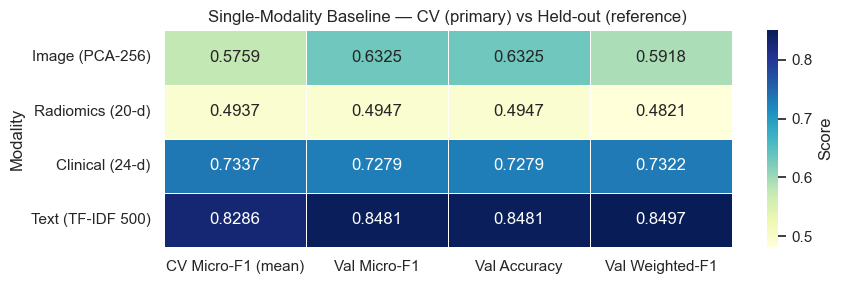

In [13]:
# ── 2.1.1  Summary comparison table (CV + held-out) ──
summary_rows = []
for mod, d in single_detail.items():
    summary_rows.append({
        'Modality': mod,
        'CV Micro-F1 (mean)': d['cv_mean'],
        'CV Micro-F1 (std)': d['cv_std'],
        'Val Micro-F1': d['micro_f1'],
        'Val Accuracy': d['accuracy'],
        'Val Weighted-F1': d['weighted_f1'],
    })
df_summary = pd.DataFrame(summary_rows).set_index('Modality')
print('Single-Modality Performance Summary')
print('  CV = Stratified 5-Fold on train.json (primary)')
print('  Val = Held-out val.json (reference)')
print('=' * 70)
print(df_summary.to_string(float_format='{:.4f}'.format))

fig, ax = plt.subplots(figsize=(9, 3))
df_plot = df_summary[['CV Micro-F1 (mean)', 'Val Micro-F1', 'Val Accuracy', 'Val Weighted-F1']]
sns.heatmap(df_plot, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Single-Modality Baseline — CV (primary) vs Held-out (reference)')
plt.tight_layout()
plt.show()

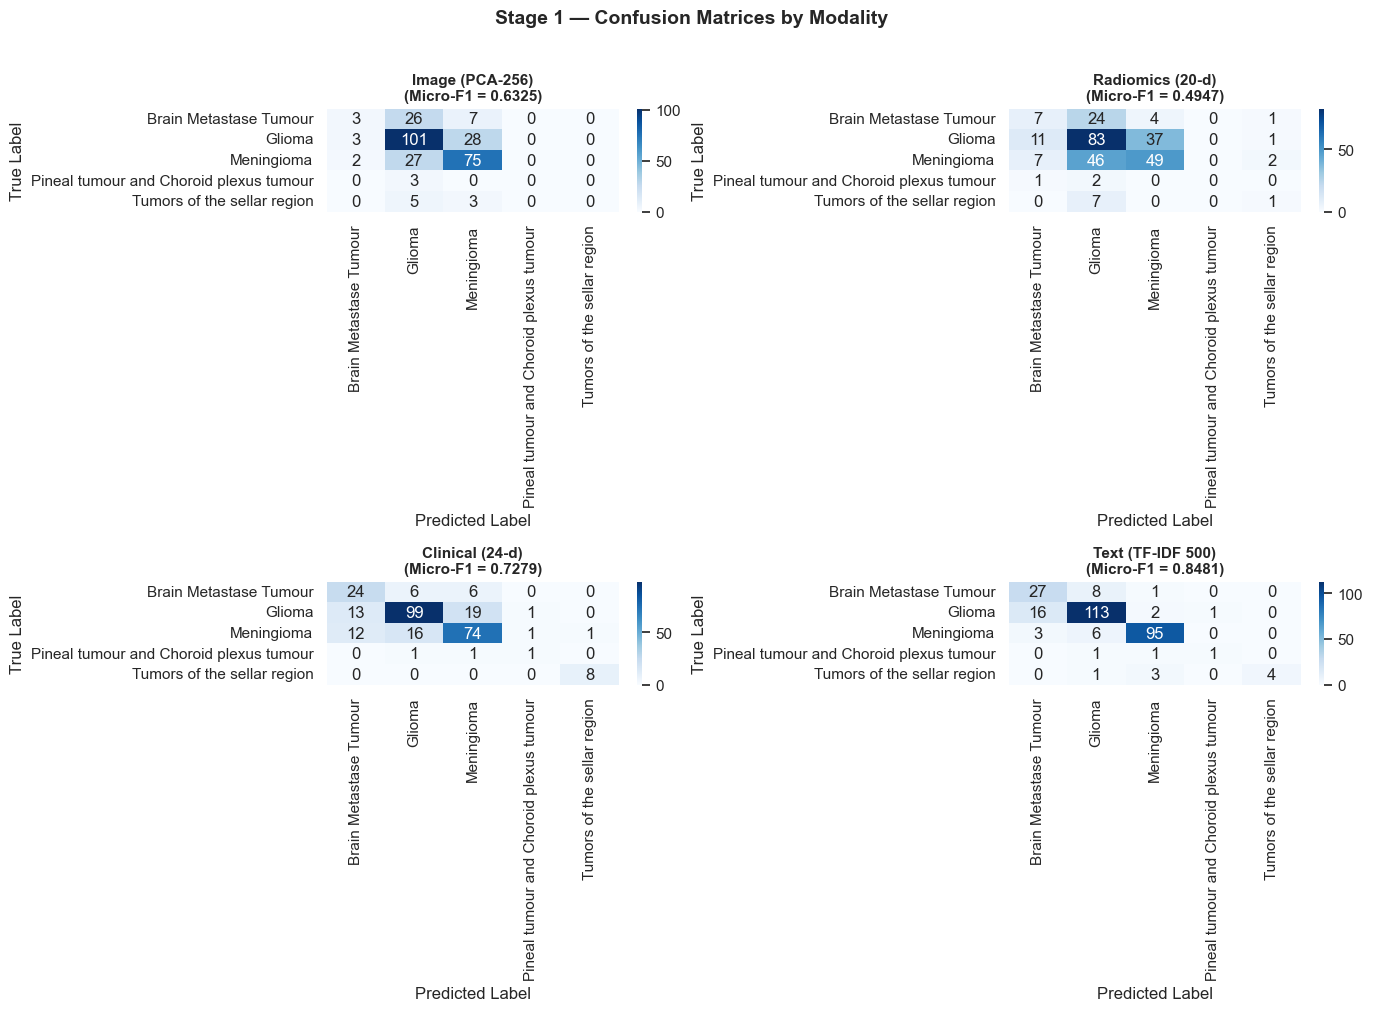

In [14]:
# ── 2.1.2  Confusion matrices (2×2 grid) ──
class_names = label_encoder.classes_
modalities = list(single_detail.keys())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()
for idx, mod in enumerate(modalities):
    cm = confusion_matrix(y_val, single_detail[mod]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx])
    axes[idx].set_title(f'{mod}\n(Micro-F1 = {single_detail[mod]["micro_f1"]:.4f})',
                        fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.suptitle('Stage 1 — Confusion Matrices by Modality', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

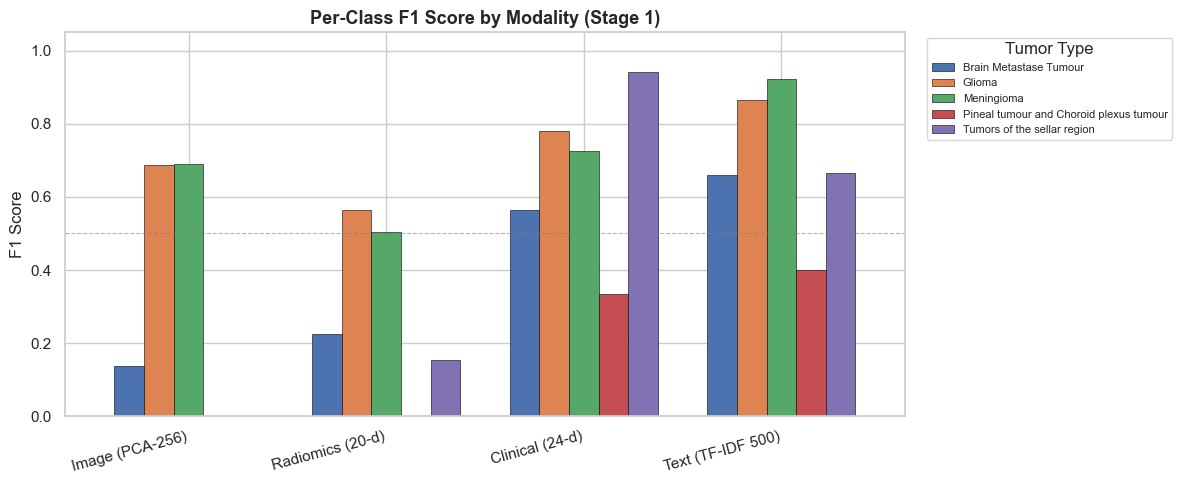


Per-class F1 detail:
                   Brain Metastase Tumour  Glioma  Meningioma  Pineal tumour and Choroid plexus tumour  Tumors of the sellar region
Image (PCA-256)                    0.1364  0.6871      0.6912                                   0.0000                       0.0000
Radiomics (20-d)                   0.2258  0.5646      0.5052                                   0.0000                       0.1538
Clinical (24-d)                    0.5647  0.7795      0.7255                                   0.3333                       0.9412
Text (TF-IDF 500)                  0.6585  0.8659      0.9223                                   0.4000                       0.6667


In [15]:
# ── 2.1.3  Per-class F1 grouped bar chart ──
from sklearn.metrics import f1_score as _f1

per_class_data = {}
for mod, d in single_detail.items():
    per_class_f1 = _f1(y_val, d['y_pred'], average=None, labels=range(len(class_names)))
    per_class_data[mod] = per_class_f1

df_perclass = pd.DataFrame(per_class_data, index=class_names).T

fig, ax = plt.subplots(figsize=(12, 5))
df_perclass.plot(kind='bar', ax=ax, width=0.75, edgecolor='black', linewidth=0.4)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score by Modality (Stage 1)', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.legend(title='Tumor Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.show()

print('\nPer-class F1 detail:')
print(df_perclass.round(4).to_string())

---
# 3. Stage 2 — Multimodal Fusion

We compare **early fusion** (concatenated features → single model) and **late fusion** (combine single-modality predictions).

## 3.1 Early Fusion — Model Comparison

Using the 800-d concatenated feature set, we train models of increasing flexibility.

In [16]:
def evaluate_model(model, X_val, y_val, name='Model', run_cv=True):
    """
    Two-step evaluation per Lecture 4.1:
      1. Stratified 5-fold CV on training set  →  primary (model selection)
         Uses sklearn.base.clone so the fitted model is preserved.
      2. Evaluate fitted model on held-out val  →  reference
    """
    cv_scores = None
    if run_cv:
        cv_pipe = make_pipeline(StandardScaler(), clone(model))
        cv_scores = cross_val_score(cv_pipe, X_train_all, y_train,
                                    cv=skf, scoring='f1_micro', n_jobs=-1)

    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    f1m = f1_score(y_val, y_pred, average='micro')
    f1w = f1_score(y_val, y_pred, average='weighted')

    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val)

    print(f'\n{"="*60}')
    print(f'  {name}')
    print(f'{"="*60}')
    if cv_scores is not None:
        print(f'  [CV]  Micro-F1 = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
              f'(folds: {", ".join(f"{s:.3f}" for s in cv_scores)})')
    print(f'  [Val] Micro-F1 = {f1m:.4f}  |  Accuracy = {acc:.4f}  |  '
          f'Weighted-F1 = {f1w:.4f}')
    print(f'\nClassification Report (held-out val):')
    print(classification_report(y_val, y_pred,
                                target_names=label_encoder.classes_, digits=4))

    result = {'micro_f1': f1m, 'accuracy': acc, 'weighted_f1': f1w,
              'y_pred': y_pred, 'y_proba': y_proba}
    if cv_scores is not None:
        result['cv_scores'] = cv_scores
        result['cv_mean'] = cv_scores.mean()
        result['cv_std'] = cv_scores.std()
    return result

early_results = {}
early_detail = {}

In [17]:
# 3.1.1 Logistic Regression (L2) — linear baseline
lr = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced',
                        multi_class='multinomial', solver='lbfgs', random_state=SEED)
lr.fit(X_train_scaled, y_train)
early_detail['LR (L2)'] = evaluate_model(lr, X_val_scaled, y_val, 'Logistic Regression (L2)')
early_results['LR (L2)'] = early_detail['LR (L2)']['micro_f1']


  Logistic Regression (L2)
  [CV]  Micro-F1 = 0.7806 ± 0.0188  (folds: 0.806, 0.771, 0.796, 0.753, 0.778)
  [Val] Micro-F1 = 0.7915  |  Accuracy = 0.7915  |  Weighted-F1 = 0.7987

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.4800    0.6667    0.5581        36
                                 Glioma     0.8500    0.7727    0.8095       132
                             Meningioma     0.8835    0.8750    0.8792       104
Pineal tumour and Choroid plexus tumour     0.4000    0.6667    0.5000         3
            Tumors of the sellar region     1.0000    0.6250    0.7692         8

                               accuracy                         0.7915       283
                              macro avg     0.7227    0.7212    0.7032       283
                           weighted avg     0.8147    0.7915    0.7987       283



In [18]:
# 3.1.2 Random Forest — bagging ensemble
rf = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2,
                            class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
early_detail['RF'] = evaluate_model(rf, X_val_scaled, y_val, 'Random Forest')
early_results['RF'] = early_detail['RF']['micro_f1']


  Random Forest
  [CV]  Micro-F1 = 0.7110 ± 0.0283  (folds: 0.683, 0.741, 0.725, 0.735, 0.672)
  [Val] Micro-F1 = 0.7279  |  Accuracy = 0.7279  |  Weighted-F1 = 0.6981

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.7500    0.1667    0.2727        36
                                 Glioma     0.6800    0.9015    0.7752       132
                             Meningioma     0.8105    0.7404    0.7739       104
Pineal tumour and Choroid plexus tumour     0.0000    0.0000    0.0000         3
            Tumors of the sellar region     0.8000    0.5000    0.6154         8

                               accuracy                         0.7279       283
                              macro avg     0.6081    0.4617    0.4874       283
                           weighted avg     0.7331    0.7279    0.6981       283



In [19]:
# 3.1.3 SVM (RBF kernel)
svm = SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced',
          random_state=SEED, probability=True)
svm.fit(X_train_scaled, y_train)
early_detail['SVM-RBF'] = evaluate_model(svm, X_val_scaled, y_val, 'SVM (RBF)')
early_results['SVM-RBF'] = early_detail['SVM-RBF']['micro_f1']


  SVM (RBF)
  [CV]  Micro-F1 = 0.8346 ± 0.0191  (folds: 0.854, 0.846, 0.849, 0.818, 0.806)
  [Val] Micro-F1 = 0.8587  |  Accuracy = 0.8587  |  Weighted-F1 = 0.8581

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6316    0.6667    0.6486        36
                                 Glioma     0.8540    0.8864    0.8699       132
                             Meningioma     0.9412    0.9231    0.9320       104
Pineal tumour and Choroid plexus tumour     1.0000    0.6667    0.8000         3
            Tumors of the sellar region     1.0000    0.5000    0.6667         8

                               accuracy                         0.8587       283
                              macro avg     0.8854    0.7286    0.7834       283
                           weighted avg     0.8634    0.8587    0.8581       283



In [20]:
# 3.1.4 XGBoost — boosting ensemble
xgb_model = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', num_class=5,
    eval_metric='mlogloss', random_state=SEED, use_label_encoder=False)
xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)
early_detail['XGB'] = evaluate_model(xgb_model, X_val_scaled, y_val, 'XGBoost')
early_results['XGB'] = early_detail['XGB']['micro_f1']


  XGBoost
  [CV]  Micro-F1 = 0.7877 ± 0.0085  (folds: 0.781, 0.796, 0.776, 0.798, 0.788)
  [Val] Micro-F1 = 0.8233  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8205

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5938    0.5278    0.5588        36
                                 Glioma     0.8085    0.8636    0.8352       132
                             Meningioma     0.9109    0.8846    0.8976       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8233       283
                              macro avg     0.8376    0.6969    0.7333       283
                           weighted avg     0.8227    0.8233    0.8205       283



In [21]:
# 3.1.5 LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, num_leaves=63,
    class_weight='balanced', random_state=SEED, verbose=-1)
lgb_model.fit(X_train_scaled, y_train)
early_detail['LGB'] = evaluate_model(lgb_model, X_val_scaled, y_val, 'LightGBM')
early_results['LGB'] = early_detail['LGB']['micro_f1']


  LightGBM
  [CV]  Micro-F1 = 0.8109 ± 0.0174  (folds: 0.781, 0.816, 0.806, 0.833, 0.818)
  [Val] Micro-F1 = 0.8233  |  Accuracy = 0.8233  |  Weighted-F1 = 0.8176

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6071    0.4722    0.5312        36
                                 Glioma     0.8156    0.8712    0.8425       132
                             Meningioma     0.8857    0.8942    0.8900       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8233       283
                              macro avg     0.8367    0.6892    0.7277       283
                           weighted avg     0.8185    0.8233    0.8176       283



In [22]:
# 3.1.6 MLP Neural Network
mlp = MLPClassifier(hidden_layer_sizes=(512, 256, 128), activation='relu',
    max_iter=500, early_stopping=True, validation_fraction=0.1,
    batch_size=64, learning_rate='adaptive', learning_rate_init=0.001, random_state=SEED)
mlp.fit(X_train_scaled, y_train)
early_detail['MLP'] = evaluate_model(mlp, X_val_scaled, y_val, 'MLP')
early_results['MLP'] = early_detail['MLP']['micro_f1']


  MLP
  [CV]  Micro-F1 = 0.8180 ± 0.0123  (folds: 0.834, 0.796, 0.821, 0.821, 0.818)
  [Val] Micro-F1 = 0.8375  |  Accuracy = 0.8375  |  Weighted-F1 = 0.8370

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5952    0.6944    0.6410        36
                                 Glioma     0.8605    0.8409    0.8506       132
                             Meningioma     0.9057    0.9231    0.9143       104
Pineal tumour and Choroid plexus tumour     1.0000    0.3333    0.5000         3
            Tumors of the sellar region     0.8000    0.5000    0.6154         8

                               accuracy                         0.8375       283
                              macro avg     0.8323    0.6584    0.7043       283
                           weighted avg     0.8431    0.8375    0.8370       283



## 3.2 Late Fusion — Voting & Stacking

Combine predictions from individually strong models. This preserves modality-specific structure.

In [23]:
late_results = {}
late_detail = {}

# 3.2.1 Soft Voting (early-fusion models combined by probability averaging)
# Note: run_cv=False for ensemble wrappers — CV is done on base learners above
voting_clf = VotingClassifier(estimators=[
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=SEED, probability=True)),
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, num_leaves=63, class_weight='balanced', random_state=SEED, verbose=-1)),
    ('lr', LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', multi_class='multinomial', random_state=SEED)),
], voting='soft')
voting_clf.fit(X_train_scaled, y_train)
late_detail['Soft Voting'] = evaluate_model(voting_clf, X_val_scaled, y_val,
                                            'Late Fusion: Soft Voting', run_cv=False)
late_results['Soft Voting'] = late_detail['Soft Voting']['micro_f1']


  Late Fusion: Soft Voting
  [Val] Micro-F1 = 0.8445  |  Accuracy = 0.8445  |  Weighted-F1 = 0.8442

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.6000    0.5833    0.5915        36
                                 Glioma     0.8507    0.8636    0.8571       132
                             Meningioma     0.9223    0.9135    0.9179       104
Pineal tumour and Choroid plexus tumour     0.6667    0.6667    0.6667         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8445       283
                              macro avg     0.7829    0.7804    0.7816       283
                           weighted avg     0.8439    0.8445    0.8442       283



In [24]:
# 3.2.2 Stacking (meta-learner: LR on base model outputs, internal 5-fold CV)
# StackingClassifier already uses cv=5 internally for generating meta-features
stacking_clf = StackingClassifier(estimators=[
    ('svm', SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', random_state=SEED, probability=True)),
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=500, max_depth=8, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, num_leaves=63, class_weight='balanced', random_state=SEED, verbose=-1)),
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=2, class_weight='balanced', random_state=SEED)),
], final_estimator=LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED), cv=5)
stacking_clf.fit(X_train_scaled, y_train)
late_detail['Stacking'] = evaluate_model(stacking_clf, X_val_scaled, y_val,
                                         'Late Fusion: Stacking', run_cv=False)
late_results['Stacking'] = late_detail['Stacking']['micro_f1']


  Late Fusion: Stacking
  [Val] Micro-F1 = 0.8304  |  Accuracy = 0.8304  |  Weighted-F1 = 0.8409

Classification Report (held-out val):
                                         precision    recall  f1-score   support

                 Brain Metastase Tumour     0.5294    0.7500    0.6207        36
                                 Glioma     0.9043    0.7879    0.8421       132
                             Meningioma     0.9406    0.9135    0.9268       104
Pineal tumour and Choroid plexus tumour     0.2500    0.6667    0.3636         3
            Tumors of the sellar region     0.8750    0.8750    0.8750         8

                               accuracy                         0.8304       283
                              macro avg     0.6999    0.7986    0.7257       283
                           weighted avg     0.8622    0.8304    0.8409       283



## 3.3 Stage 2 — Comprehensive Result Comparison (Tutorial 7 Style)

Following Tutorial 7's reporting pattern, we produce:
1. **Summary table** with Accuracy, Micro-F1, Weighted-F1, and macro-averaged AUROC
2. **Confusion matrix grid** for all fusion models
3. **Multiclass ROC curves** (One-vs-Rest, macro-averaged)
4. **Precision–Recall curves** (One-vs-Rest)

FULL MODEL COMPARISON
  CV = 5-Fold on train.json (primary)  |  Val = held-out val.json (reference)
                 CV Micro-F1  Val Micro-F1  Val Accuracy  Val Weighted-F1  AUROC (macro)
Model                                                                                   
SVM-RBF      0.8346 ± 0.0191      0.858657      0.858657         0.858099       0.963306
Soft Voting                —      0.844523      0.844523         0.844161       0.965465
MLP          0.8180 ± 0.0123      0.837456      0.837456         0.836967       0.921894
Stacking                   —      0.830389      0.830389         0.840932       0.955680
XGB          0.7877 ± 0.0085      0.823322      0.823322         0.820515       0.962648
LGB          0.8109 ± 0.0174      0.823322      0.823322         0.817628       0.958518
LR (L2)      0.7806 ± 0.0188      0.791519      0.791519         0.798741       0.946254
RF           0.7110 ± 0.0283      0.727915      0.727915         0.698077       0.933709


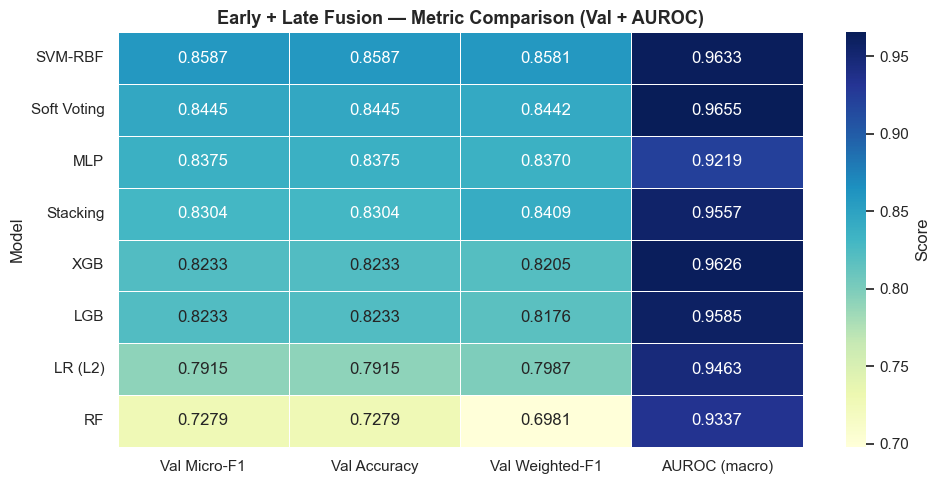

In [25]:
# ── 3.3.1  Comprehensive summary table (CV + Val + AUROC) ──
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

all_detail = {**early_detail, **late_detail}
n_classes = len(label_encoder.classes_)
y_val_bin = label_binarize(y_val, classes=range(n_classes))

summary_rows = []
for name, d in all_detail.items():
    row = {'Model': name,
           'CV Micro-F1': f"{d.get('cv_mean', float('nan')):.4f} ± {d.get('cv_std', float('nan')):.4f}"
                          if 'cv_mean' in d else '—',
           'Val Micro-F1': d['micro_f1'],
           'Val Accuracy': d['accuracy'],
           'Val Weighted-F1': d['weighted_f1']}
    if d['y_proba'] is not None:
        row['AUROC (macro)'] = roc_auc_score(y_val_bin, d['y_proba'],
                                              average='macro', multi_class='ovr')
    else:
        row['AUROC (macro)'] = float('nan')
    summary_rows.append(row)

df_fusion = pd.DataFrame(summary_rows).set_index('Model')
df_fusion_numeric = df_fusion.drop(columns=['CV Micro-F1']).sort_values('Val Micro-F1', ascending=False)

print('FULL MODEL COMPARISON')
print('  CV = 5-Fold on train.json (primary)  |  Val = held-out val.json (reference)')
print('=' * 80)
print(df_fusion.sort_values('Val Micro-F1', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df_fusion_numeric, annot=True, fmt='.4f', cmap='YlGnBu', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Early + Late Fusion — Metric Comparison (Val + AUROC)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

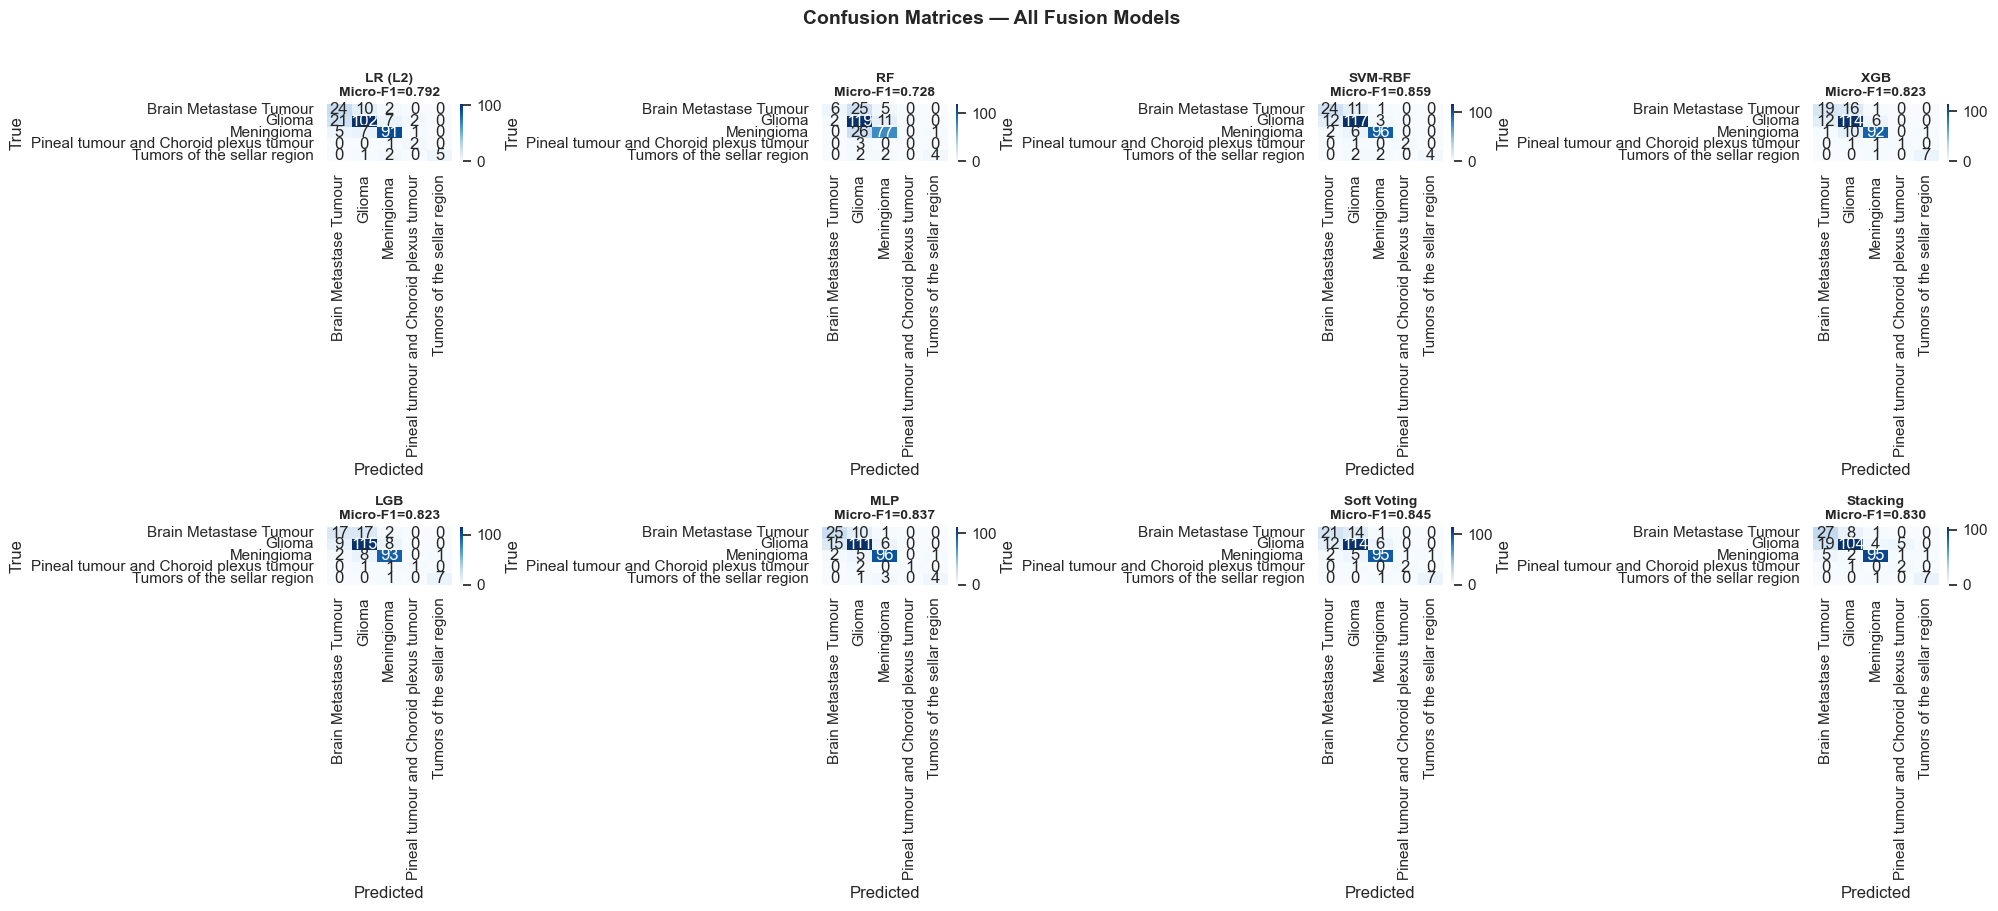

In [26]:
# ── 3.3.2  Confusion matrix grid for all fusion models ──
model_names = list(all_detail.keys())
n_models = len(model_names)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.ravel() if n_models > 1 else [axes]

for idx, name in enumerate(model_names):
    cm = confusion_matrix(y_val, all_detail[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                ax=axes[idx])
    axes[idx].set_title(f'{name}\nMicro-F1={all_detail[name]["micro_f1"]:.3f}',
                        fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Confusion Matrices — All Fusion Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

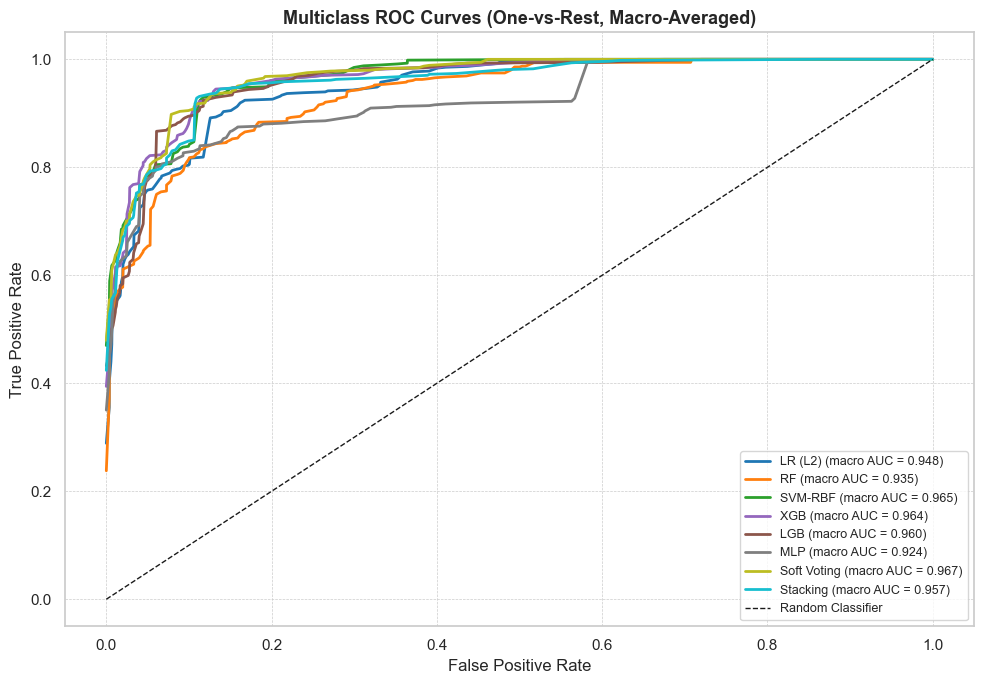

In [27]:
# ── 3.3.3  Multiclass ROC curves (One-vs-Rest, macro-averaged) ──
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, len(all_detail)))

for (name, d), color in zip(all_detail.items(), colors):
    if d['y_proba'] is None:
        continue
    fpr_macro, tpr_macro = dict(), dict()
    for i in range(n_classes):
        fpr_macro[i], tpr_macro[i], _ = roc_curve(y_val_bin[:, i], d['y_proba'][:, i])
    all_fpr = np.unique(np.concatenate([fpr_macro[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr_macro[i], tpr_macro[i])
    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)
    ax.plot(all_fpr, mean_tpr, color=color, lw=2,
            label=f'{name} (macro AUC = {macro_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Multiclass ROC Curves (One-vs-Rest, Macro-Averaged)', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

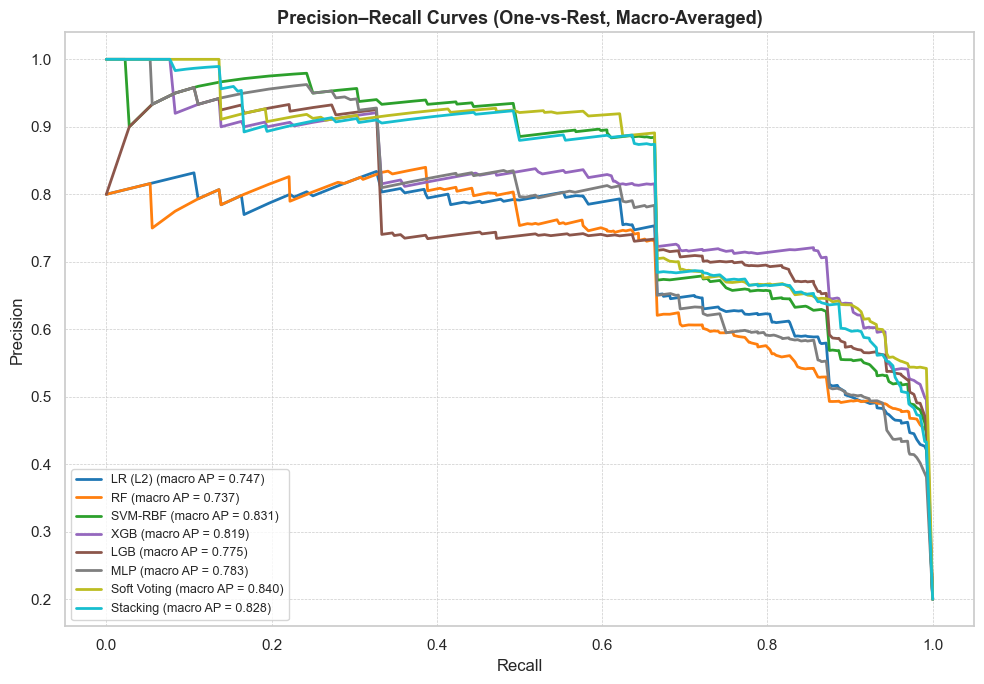

In [28]:
# ── 3.3.4  Precision–Recall curves (One-vs-Rest, macro-averaged) ──
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(10, 7))

for (name, d), color in zip(all_detail.items(), colors):
    if d['y_proba'] is None:
        continue
    prec_avg, rec_avg = dict(), dict()
    for i in range(n_classes):
        prec_avg[i], rec_avg[i], _ = precision_recall_curve(y_val_bin[:, i], d['y_proba'][:, i])
    macro_ap = average_precision_score(y_val_bin, d['y_proba'], average='macro')
    all_recall = np.unique(np.concatenate([rec_avg[i] for i in range(n_classes)]))
    mean_prec = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_prec += np.interp(all_recall, rec_avg[i][::-1], prec_avg[i][::-1])
    mean_prec /= n_classes
    ax.plot(all_recall, mean_prec, color=color, lw=2,
            label=f'{name} (macro AP = {macro_ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision–Recall Curves (One-vs-Rest, Macro-Averaged)', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=9)
ax.grid(visible=True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

---
# 4. Stage 3 — Optimization *(TODO sections for team)*

The cells below are placeholders for experiments to be completed during Apr 9–13.

### 4.1 Feature Selection
- Compare LASSO (L1) vs RF importance vs MI ranking
- Remove radiomics pairs with |r| > 0.95
- Tune PCA components (128 / 256 / 512)

### 4.2 Class Imbalance Experiments
- (a) class_weight='balanced' (current default)
- (b) Random oversampling of minority classes (train only)
- (c) SMOTE in PCA-reduced feature space (train only)
- Report per-class F1 and micro-F1 for each strategy

### 4.3 Hyperparameter Tuning
- Stratified 5-fold CV on train set for top-2 models
- Grid search over key parameters (e.g., LGB n_estimators, max_depth, learning_rate)

---
# 5. Model Analysis

Targeting the workload/analysis component (40% of grade).

## 5.1 Model Comparison Summary (Early + Late Fusion)

In [29]:
all_results = {**early_results, **late_results}

print('\n' + '=' * 70)
print('FULL MODEL COMPARISON  (CV = primary, Val = reference)')
print('=' * 70)
for name, f1 in sorted(all_results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(f1 * 50)
    d = all_detail.get(name, {})
    cv_str = f'CV {d["cv_mean"]:.4f}±{d["cv_std"]:.4f}' if 'cv_mean' in d else '     —      '
    print(f'{name:15s} | {cv_str} | Val {f1:.4f} | {bar}')
best_name = max(all_results, key=all_results.get)
print(f'\n*** Best: {best_name} (Val Micro-F1 = {all_results[best_name]:.4f}) ***')


FULL MODEL COMPARISON  (CV = primary, Val = reference)
SVM-RBF         | CV 0.8346±0.0191 | Val 0.8587 | ██████████████████████████████████████████
Soft Voting     |      —       | Val 0.8445 | ██████████████████████████████████████████
MLP             | CV 0.8180±0.0123 | Val 0.8375 | █████████████████████████████████████████
Stacking        |      —       | Val 0.8304 | █████████████████████████████████████████
XGB             | CV 0.7877±0.0085 | Val 0.8233 | █████████████████████████████████████████
LGB             | CV 0.8109±0.0174 | Val 0.8233 | █████████████████████████████████████████
LR (L2)         | CV 0.7806±0.0188 | Val 0.7915 | ███████████████████████████████████████
RF              | CV 0.7110±0.0283 | Val 0.7279 | ████████████████████████████████████

*** Best: SVM-RBF (Val Micro-F1 = 0.8587) ***


## 5.2 Modality Ablation Study

In [30]:
feature_groups = {
    'Image Only':       (X_img_train_pca, X_img_val_pca),
    'Radiomics Only':   (X_rad_train, X_rad_val),
    'Clinical Only':    (X_clin_train, X_clin_val),
    'Text Only':        (X_text_train, X_text_val),
    'Img+Rad':          (np.hstack([X_img_train_pca, X_rad_train]), np.hstack([X_img_val_pca, X_rad_val])),
    'Img+Clin':         (np.hstack([X_img_train_pca, X_clin_train]), np.hstack([X_img_val_pca, X_clin_val])),
    'Img+Text':         (np.hstack([X_img_train_pca, X_text_train]), np.hstack([X_img_val_pca, X_text_val])),
    'All (Early Fusion)': (X_train_all, X_val_all),
}

ablation = {}
for name, (Xtr, Xva) in feature_groups.items():
    sc = StandardScaler()
    m = lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05,
                           class_weight='balanced', random_state=SEED, verbose=-1)
    m.fit(sc.fit_transform(Xtr), y_train)
    ablation[name] = f1_score(y_val, m.predict(sc.transform(Xva)), average='micro')

print('\nMODALITY ABLATION (LightGBM, Micro-F1)')
print('='*45)
for name, f1 in sorted(ablation.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:22s} | {f1:.4f}')


MODALITY ABLATION (LightGBM, Micro-F1)
  Text Only              | 0.8481
  All (Early Fusion)     | 0.8198
  Img+Text               | 0.8163
  Clinical Only          | 0.7279
  Img+Clin               | 0.7032
  Image Only             | 0.6325
  Img+Rad                | 0.6254
  Radiomics Only         | 0.4947


## 5.3 Feature Importance & Interpretability (Tutorial 7/8 Style)

We compare feature importances from two tree-based models (Random Forest and LightGBM) to identify the most discriminative features. Additional SHAP analysis can be added during the report writing phase.

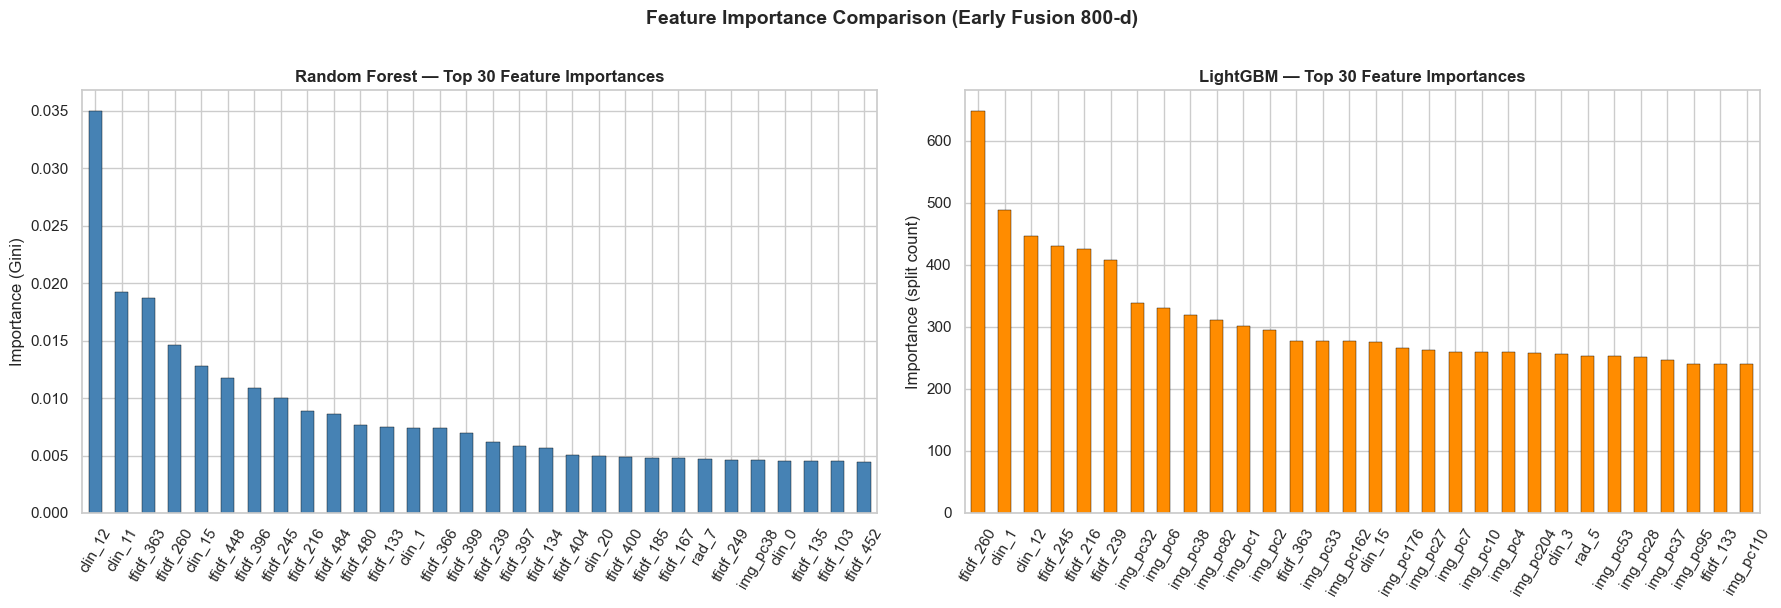


Feature source breakdown in RF Top-30:
  Image       : 1/30
  Radiomics   : 1/30
  Clinical    : 6/30
  Text        : 22/30

Feature source breakdown in LGB Top-30:
  Image       : 19/30
  Radiomics   : 1/30
  Clinical    : 4/30
  Text        : 6/30


In [31]:
# ── 5.3.1  Build feature name list matching the 800-d concatenated vector ──
img_names  = [f'img_pc{i}' for i in range(X_img_train_pca.shape[1])]
rad_names  = [f'rad_{c}' for c in range(X_rad_train.shape[1])]
clin_names = [f'clin_{i}' for i in range(X_clin_train.shape[1])]
text_names = [f'tfidf_{i}' for i in range(X_text_train.shape[1])]
all_feat_names = img_names + rad_names + clin_names + text_names

# ── 5.3.2  Random Forest — Top 30 feature importances ──
rf_imp = pd.Series(rf.feature_importances_, index=all_feat_names).sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

rf_imp.head(30).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', linewidth=0.3)
axes[0].set_title('Random Forest — Top 30 Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Importance (Gini)')
axes[0].tick_params(axis='x', rotation=60)

# ── 5.3.3  LightGBM — Top 30 feature importances ──
lgb_imp = pd.Series(lgb_model.feature_importances_, index=all_feat_names).sort_values(ascending=False)
lgb_imp.head(30).plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black', linewidth=0.3)
axes[1].set_title('LightGBM — Top 30 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Importance (split count)')
axes[1].tick_params(axis='x', rotation=60)

plt.suptitle('Feature Importance Comparison (Early Fusion 800-d)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# modality breakdown
print('\nFeature source breakdown in RF Top-30:')
top30_rf = rf_imp.head(30).index
for prefix, label in [('img_', 'Image'), ('rad_', 'Radiomics'), ('clin_', 'Clinical'), ('tfidf_', 'Text')]:
    count = sum(1 for f in top30_rf if f.startswith(prefix))
    print(f'  {label:12s}: {count}/30')

print('\nFeature source breakdown in LGB Top-30:')
top30_lgb = lgb_imp.head(30).index
for prefix, label in [('img_', 'Image'), ('rad_', 'Radiomics'), ('clin_', 'Clinical'), ('tfidf_', 'Text')]:
    count = sum(1 for f in top30_lgb if f.startswith(prefix))
    print(f'  {label:12s}: {count}/30')

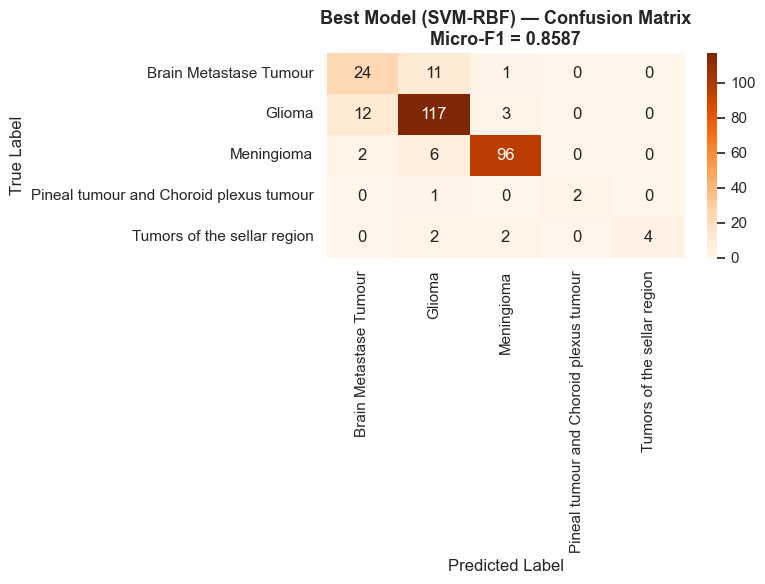


Most confused class pairs (off-diagonal max):
                                    Glioma → predicted as Brain Metastase Tumour         (12 cases)
                    Brain Metastase Tumour → predicted as Glioma                         (11 cases)
                                Meningioma → predicted as Glioma                         (6 cases)


In [32]:
# ── 5.3.4  Confusion matrix of the BEST model (error analysis) ──
best_detail = all_detail[best_name]
cm_best = confusion_matrix(y_val, best_detail['y_pred'])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_, ax=ax)
ax.set_title(f'Best Model ({best_name}) — Confusion Matrix\n'
             f'Micro-F1 = {best_detail["micro_f1"]:.4f}',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f'\nMost confused class pairs (off-diagonal max):')
np.fill_diagonal(cm_best, 0)
for _ in range(3):
    r, c = np.unravel_index(cm_best.argmax(), cm_best.shape)
    print(f'  {label_encoder.classes_[r]:>40s} → predicted as '
          f'{label_encoder.classes_[c]:<30s} ({cm_best[r, c]} cases)')
    cm_best[r, c] = 0

---
# 6. Generate Kaggle Submission

In [34]:
model_map = {'LR (L2)': lr, 'RF': rf, 'SVM-RBF': svm, 'XGB': xgb_model,
             'LGB': lgb_model, 'MLP': mlp,
             'Soft Voting': voting_clf, 'Stacking': stacking_clf}
best_model = model_map[best_name]
print(f'Using best model: {best_name}')

y_test_pred = best_model.predict(X_test_scaled)
submission = pd.DataFrame({'case_id': [int(c) for c in test_ids],
                           'Overall_class': label_encoder.inverse_transform(y_test_pred)})
sample_sub = pd.read_csv(TEST_ROOT / 'sample_submission.csv')
submission = submission.set_index('case_id').loc[sample_sub['case_id']].reset_index()
assert len(submission) == len(sample_sub), (
    f'Got {len(submission)} rows but sample_submission has {len(sample_sub)} — '
    'regenerate after updating dataset (test set size changed; do not upload old baseline_backup/submission.csv).'
)
sub_path = Path.cwd() / 'submission.csv'
for d in [Path.cwd(), *Path.cwd().resolve().parents]:
    nd = d / 'notebooks'
    if nd.is_dir() and ((nd / 'pipeline_macro.ipynb').is_file() or (nd / 'pipeline_micro.ipynb').is_file()):
        sub_path = nd / 'submission.csv'
        break
submission.to_csv(sub_path, index=False)
print(f'\nWrote: {sub_path.resolve()}')
print(f'Submission saved ({len(submission)} rows; must match Kaggle test count, currently 378). Distribution:')
print(submission['Overall_class'].value_counts())

Using best model: SVM-RBF

Wrote: /Users/sunnie/Desktop/STAT3612-Amateur-Neuro-Team/notebooks/submission.csv
Submission saved (378 rows; must match Kaggle test count, currently 378). Distribution:
Overall_class
Glioma                                     193
Meningioma                                 112
Brain Metastase Tumour                      53
Tumors of the sellar region                 16
Pineal tumour and Choroid plexus tumour      4
Name: count, dtype: int64
